<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/02_%ED%8C%8C%EC%9D%BC%ED%86%A0%EC%B9%98%EC%9D%98_%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EB%8A%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# # 나눔고딕 폰트 설치
# !apt-get update -qq
# !apt-get install -y fonts-nanum

In [2]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

0 upgraded, 0 newly installed, 0 to remove and 19 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direc

In [3]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [4]:
# 기본 설정값 변경

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
# 필요에 따라 설정할 때는, plt.legend(fontsize=14)
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
# 필요에 따라 설정할 때는, plt.figure(figsize=(6,6))
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 공통 사전 처리
# 부록 3을 제외한 모든 노트북에는 위 셀과 통합되어 있음

# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

2.2 텐서

In [6]:
import torch

In [7]:
# 0계 텐서(스칼라)

r0 = torch.tensor(1.0).float()  # 실수형 32비트 부동소수점 형식
# .float() 미처리시 실수형 64비트 자동 변환 >> 머신러닝 에러 발생
print(type(r0))
print(r0.dtype) # 데이터 형식 확인

<class 'torch.Tensor'>
torch.float32


In [8]:
print(r0.shape) # [] 0차원 >> 스칼라
print(r0.data)

torch.Size([])
tensor(1.)


In [9]:
# 1계 텐서(벡터)

r1_np = np.array([1, 2, 3, 4, 5])
print(r1_np.shape)  # (5,)

r1 = torch.tensor(r1_np).float()
print(r1.dtype)   # torch.float32
print(r1.shape)   # torch.Size([5])
print(r1.data)    # tensor([1., 2., 3., 4., 5.])

(5,)
torch.float32
torch.Size([5])
tensor([1., 2., 3., 4., 5.])


In [10]:
# 2계 텐서(행렬)

r2_np = np.array([[1,5,6],[4,3,2]])
print(r2_np.shape)

r2 = torch.tensor(r2_np).float()
print(r2.dtype)
print(r2.shape)
print(r2.data)

(2, 3)
torch.float32
torch.Size([2, 3])
tensor([[1., 5., 6.],
        [4., 3., 2.]])


In [11]:
# 3계 텐서

# 난수 seed 초기화
torch.manual_seed(123)

r3 = torch.randn((3,2,2)) # 3계(차원) 2행 2열
# random : 무작위, 임의적 >> 일반화
# randn(normalize) >> 정규분포 평균 0, 표준편차 1
print(r3.shape)
print(r3.data)

torch.Size([3, 2, 2])
tensor([[[-0.1115,  0.1204],
         [-0.3696, -0.2404]],

        [[-1.1969,  0.2093],
         [-0.9724, -0.7550]],

        [[ 0.3239, -0.1085],
         [ 0.2103, -0.3908]]])


In [12]:
# 4계 텐서

r4 = torch.ones((2,3,2,2))
print(r4.shape)
print(r4.data)

torch.Size([2, 3, 2, 2])
tensor([[[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]],


        [[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]]])


In [13]:
# 정수값

r5 = r1.long()
print(r5.dtype)
print(r5.shape)
print(r5.data)

torch.int64
torch.Size([5])
tensor([1, 2, 3, 4, 5])


In [14]:
# 2계화
# -1 지정하면, 자동으로 수를 조정
print(r3.shape)
print(r3.data)

torch.Size([3, 2, 2])
tensor([[[-0.1115,  0.1204],
         [-0.3696, -0.2404]],

        [[-1.1969,  0.2093],
         [-0.9724, -0.7550]],

        [[ 0.3239, -0.1085],
         [ 0.2103, -0.3908]]])


In [15]:
r6 = r3.view(3, -1)
print(r6.shape)
print(r6.data)

torch.Size([3, 4])
tensor([[-0.1115,  0.1204, -0.3696, -0.2404],
        [-1.1969,  0.2093, -0.9724, -0.7550],
        [ 0.3239, -0.1085,  0.2103, -0.3908]])


In [16]:
# 1계화

r7 = r3.view(-1)
print(r7.shape)
print(r7.data)

torch.Size([12])
tensor([-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
         0.3239, -0.1085,  0.2103, -0.3908])


In [17]:
# requires_grad 속성
print(r1.requires_grad)

# device 속성
print(r1.device)

False
cpu


In [18]:
# item 함수
# 스칼라 텐서
item = r0.item()
print(type(item))
print(item)

<class 'float'>
1.0


In [19]:
# r1.item()

# RuntimeError                              Traceback (most recent call last)
# /tmp/ipykernel_3119/299471224.py in <cell line: 0>()
# ----> 1 r1.item()

# RuntimeError: a Tensor with 5 elements cannot be converted to Scalar


In [20]:
# shape[1], [1.1] 처럼 요소가 1개밖에 없는 경우 사용 가능
t1 = torch.ones(1)
print(t1.shape)
print(t1.item())

torch.Size([1])
1.0


In [21]:
# max 함수
print(r2)
print(r2.max())

tensor([[1., 5., 6.],
        [4., 3., 2.]])
tensor(6.)


In [22]:
# torch.max 함수
print(torch.max(r2,axis=1))   # axis=1, 각각 행 비교 (↓ 방향 이동)

torch.return_types.max(
values=tensor([6., 4.]),
indices=tensor([2, 0]))


In [23]:
print(torch.max(r2,axis=0))   # axis=0, 각각 열 비교 (→ 방향 이동)

torch.return_types.max(
values=tensor([4., 5., 6.]),
indices=tensor([1, 0, 0]))


In [24]:
print(torch.max(r2,axis=1)[0])  # values
print(torch.max(r2,axis=1)[1])  # indices

tensor([6., 4.])
tensor([2, 0])


In [25]:
# 넘파이로 변환
r2.data

tensor([[1., 5., 6.],
        [4., 3., 2.]])

In [26]:
r2_np = r2.data.numpy()
print(r2_np)
print(type(r2_np))

[[1. 5. 6.]
 [4. 3. 2.]]
<class 'numpy.ndarray'>


2.4 2차 함수의 경사 계산

In [27]:
x_np = np.arange(-2, 2.1, 0.25)
print(x_np)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]


In [28]:
# 경사 계산용 변수 정의
x = torch.tensor(x_np, requires_grad=True, dtype=torch.float32)
print(type(x))
print(x)

<class 'torch.Tensor'>
tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


In [29]:
# 2차 함수의 계산
y = 2 * x**2 + 2
print(type(y))
print(y)

<class 'torch.Tensor'>
tensor([10.0000,  8.1250,  6.5000,  5.1250,  4.0000,  3.1250,  2.5000,  2.1250,
         2.0000,  2.1250,  2.5000,  3.1250,  4.0000,  5.1250,  6.5000,  8.1250,
        10.0000], grad_fn=<AddBackward0>)


In [33]:
z = y.sum()

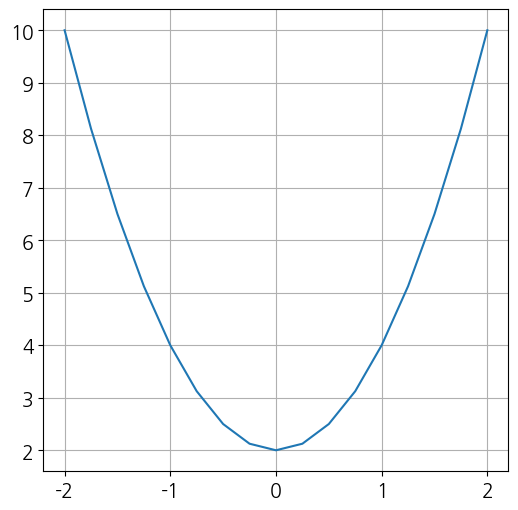

In [30]:
# 그래프 출력
plt.plot(x.detach(), y.detach())
plt.show()

In [31]:
# 그래프 시각화
# 라이브러리 임포트
!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

from torchviz import make_dot

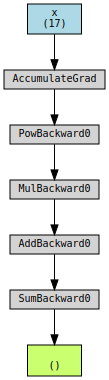

In [34]:
# 함수 호출
g = make_dot(z, params={'x': x})
display(g)

In [35]:
# 경사 계산
z.backward()

# backward() 는 기본적으로 하나의 숫자(scalar)에 대해서만 동작함
# 이전에 동작했다면 재동작 하지 않음 주

In [36]:
# 경사값
print(x.grad)

tensor([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.])


In [37]:
# 경사값 초기화 없이 두번째 경사를 계산
y = 2 * x**2 + 2
z = y.sum()
print(z)
z.backward()

print(x.grad)   # 실행할 때마다 값 누적 >> 경사값 초기화 필요 이유

tensor(85., grad_fn=<SumBackward0>)
tensor([-16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,
          8.,  10.,  12.,  14.,  16.])


In [38]:
# 경사값 초기화
x.grad.zero_()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

2.5 시그모이드 함수의 경사 계산

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

In [40]:
# sigmoid = torch.nn.Sigmoid()
sigmoid = nn.Sigmoid()

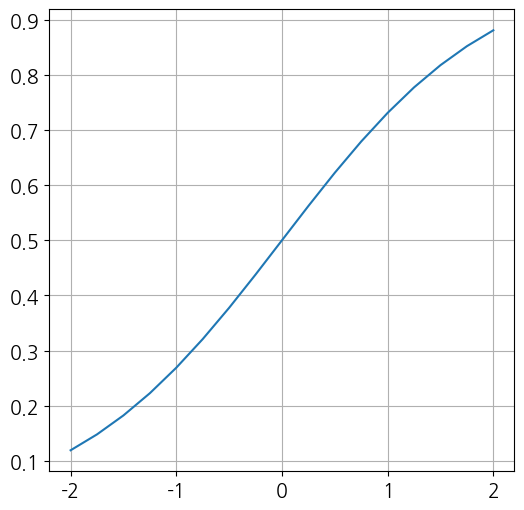

In [41]:
# 그래프 출력
y = sigmoid(x)

plt.plot(x.detach(), y.detach())
plt.show()

In [42]:
z = y.sum()
print(z)

tensor(8.5000, grad_fn=<SumBackward0>)


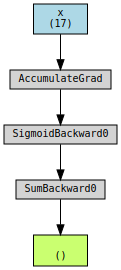

In [43]:
# 그래프 시각화
g = make_dot(z, params={"x": x})
display(g)

In [44]:
# 경사 계산
z.backward()
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])
